In [129]:
import pandas as pd
import numpy as np
import matplotlib.pyplot as plt
import seaborn as sns

In [130]:
df = pd.read_csv('covid-19-cases-in-pakistan-2020.csv')
df.head()

,Unnamed: 0,Cumulative,Cumulative Test positive,Cumulative tests performed,Date,Discharged,Expired,Home Quarantine,New (last 24 hrs),Region,Still admitted,Tests performed in last 24 hours
0,4,48,2,80,3/11/2020,0,0,NaN,3,ICT,2,8
1,5,61,0,95,3/11/2020,0,0,NaN,6,Punjab,0,7
2,6,84,14,171,3/11/2020,1,0,NaN,1,Sindh,13,55
3,7,20,0,28,3/11/2020,0,0,NaN,0,KP,0,2
4,8,3,0,0,3/11/2020,0,0,NaN,0,KPTD,0,0


In [131]:
df.info()

<class 'pandas.core.frame.DataFrame'>
RangeIndex: 643 entries, 0 to 642
Data columns (total 12 columns):
 #   Column                             Non-Null Count  Dtype  
---  ------                             --------------  -----  
 0   Unnamed: 0                         643 non-null    int64  
 1   Cumulative                         643 non-null    int64  
 2   Cumulative  Test positive          643 non-null    int64  
 3   Cumulative  tests performed        643 non-null    int64  
 4   Date                               643 non-null    object 
 5   Discharged                         643 non-null    int64  
 6   Expired                            643 non-null    int64  
 7   Home Quarantine                    504 non-null    float64
 8   New  (last 24 hrs)                 643 non-null    int64  
 9   Region                             643 non-null    object 
 10  Still admitted                     643 non-null    int64  
 11  Tests  performed in last 24 hours  643 non-null    object 

In [132]:
df.isnull().sum()

Unnamed: 0                             0
Cumulative                             0
Cumulative  Test positive              0
Cumulative  tests performed            0
Date                                   0
Discharged                             0
Expired                                0
Home Quarantine                      139
New  (last 24 hrs)                     0
Region                                 0
Still admitted                         0
Tests  performed in last 24 hours      0
dtype: int64

In [133]:
# Replace NaN with 0
df['Home Quarantine'] = df['Home Quarantine'].fillna(0)


In [134]:
df.isnull().sum()

Unnamed: 0                           0
Cumulative                           0
Cumulative  Test positive            0
Cumulative  tests performed          0
Date                                 0
Discharged                           0
Expired                              0
Home Quarantine                      0
New  (last 24 hrs)                   0
Region                               0
Still admitted                       0
Tests  performed in last 24 hours    0
dtype: int64

In [135]:
df.describe()

,Unnamed: 0,Cumulative,Cumulative Test positive,Cumulative tests performed,Discharged,Expired,Home Quarantine,New (last 24 hrs),Still admitted
count,643.000000,643.000000,643.000000,643.000000,643.000000,643.000000,643.000000,643.000000,643.000000
mean,8.853810,28049.569207,3587.626750,30525.283048,1160.814930,74.581649,1894.863142,1088.769829,472.922240
std,2.342303,52406.157576,7368.132133,56453.756905,2727.293247,150.071751,4276.542505,1917.027154,1089.114841
min,4.000000,0.000000,0.000000,0.000000,0.000000,0.000000,0.000000,0.000000,0.000000
25%,7.000000,1155.000000,86.000000,1370.500000,3.000000,1.000000,0.000000,52.000000,16.500000
50%,9.000000,6224.000000,465.000000,5976.000000,140.000000,5.000000,130.000000,240.000000,62.000000
75%,11.000000,26332.000000,3207.500000,29644.500000,731.000000,48.500000,1849.500000,1137.000000,406.000000
max,13.000000,325091.000000,47382.000000,327072.000000,22047.000000,890.000000,34520.000000,12362.000000,9418.000000


In [136]:
df.columns

Index(['Unnamed: 0', 'Cumulative', 'Cumulative  Test positive',
       'Cumulative  tests performed', 'Date', 'Discharged', 'Expired',
       'Home Quarantine', 'New  (last 24 hrs)', 'Region', 'Still admitted',
       'Tests  performed in last 24 hours'],
      dtype='object')

In [137]:
# Display settings
pd.set_option('display.max_columns', None)
pd.set_option('display.max_rows', 100)

# Basic information
print("Shape:", df.shape)
print("\nColumns:")
print(df.columns)

print("\nFirst 5 rows:")
display(df.head())

Shape: (643, 12)

Columns:
Index(['Unnamed: 0', 'Cumulative', 'Cumulative  Test positive',
       'Cumulative  tests performed', 'Date', 'Discharged', 'Expired',
       'Home Quarantine', 'New  (last 24 hrs)', 'Region', 'Still admitted',
       'Tests  performed in last 24 hours'],
      dtype='object')

First 5 rows:


,Unnamed: 0,Cumulative,Cumulative Test positive,Cumulative tests performed,Date,Discharged,Expired,Home Quarantine,New (last 24 hrs),Region,Still admitted,Tests performed in last 24 hours
0,4,48,2,80,3/11/2020,0,0,0.0,3,ICT,2,8
1,5,61,0,95,3/11/2020,0,0,0.0,6,Punjab,0,7
2,6,84,14,171,3/11/2020,1,0,0.0,1,Sindh,13,55
3,7,20,0,28,3/11/2020,0,0,0.0,0,KP,0,2
4,8,3,0,0,3/11/2020,0,0,0.0,0,KPTD,0,0


## 2. Clean column names

In [138]:
df.columns = df.columns.str.strip()
df.columns = df.columns.str.replace(r'\s+', ' ', regex=True)

print(df.columns)

Index(['Unnamed: 0', 'Cumulative', 'Cumulative Test positive',
       'Cumulative tests performed', 'Date', 'Discharged', 'Expired',
       'Home Quarantine', 'New (last 24 hrs)', 'Region', 'Still admitted',
       'Tests performed in last 24 hours'],
      dtype='object')


## 3. Remove unnecessary index column

In [139]:
if 'Unnamed: 0' in df.columns:
    df = df.drop(columns=['Unnamed: 0'])

print(df.shape)

(643, 11)


## 4. Convert Date

In [140]:
invalid_mask = pd.to_datetime(
    df['Date'],
    format='%d-%b-%Y',
    errors='coerce'
).isna()

print("Invalid dates:", invalid_mask.sum())
print(df.loc[invalid_mask, 'Date'].to_list())

Invalid dates: 608
['3/11/2020', '3/11/2020', '3/11/2020', '3/11/2020', '3/11/2020', '3/11/2020', '3/11/2020', '3/11/2020', '3/12/2020', '3/12/2020', '3/12/2020', '3/12/2020', '3/12/2020', '3/12/2020', '3/12/2020', '3/12/2020', '3/13/2020', '3/13/2020', '3/13/2020', '3/13/2020', '3/13/2020', '3/13/2020', '3/13/2020', '3/13/2020', '3/14/2020', '3/14/2020', '3/14/2020', '3/14/2020', '3/14/2020', '3/14/2020', '3/14/2020', '3/14/2020', '3/15/2020', '3/15/2020', '3/15/2020', '3/15/2020', '3/15/2020', '3/15/2020', '3/15/2020', '3/15/2020', '3/16/2020', '3/16/2020', '3/16/2020', '3/16/2020', '3/16/2020', '3/16/2020', '3/16/2020', '3/16/2020', '3/16/2020', '3/17/2020', '3/17/2020', '3/17/2020', '3/17/2020', '3/17/2020', '3/17/2020', '3/17/2020', '3/18/2020', '3/18/2020', '3/18/2020', '3/18/2020', '3/18/2020', '3/18/2020', '3/18/2020', '3/18/2020', '3/19/2020', '3/19/2020', '3/19/2020', '3/19/2020', '3/19/2020', '3/19/2020', '3/19/2020', '3/20/2020', '3/20/2020', '3/20/2020', '3/20/2020', '3/20

## Final Code

In [141]:
# Convert mixed date formats to datetime
df['Date'] = pd.to_datetime(
    df['Date'],
    format='mixed',
    errors='coerce'
)

# Check conversion
print("Date data type:", df['Date'].dtype)
print("Invalid dates:", df['Date'].isna().sum())

# Check date range
print("Start date:", df['Date'].min())
print("End date:", df['Date'].max())
print("Unique dates:", df['Date'].nunique())

Date data type: datetime64[ns]
Invalid dates: 0
Start date: 2020-03-11 00:00:00
End date: 2020-06-12 00:00:00
Unique dates: 90


## Convert COVID numerical columns to numeric

In [142]:
numeric_cols = [
    'Cumulative',
    'Cumulative Test positive',
    'Cumulative tests performed',
    'Discharged',
    'Expired',
    'Home Quarantine',
    'New (last 24 hrs)',
    'Still admitted',
    'Tests performed in last 24 hours'
]

for col in numeric_cols:
    if col in df.columns:
        df[col] = pd.to_numeric(df[col], errors='coerce')
        
df.info()

<class 'pandas.core.frame.DataFrame'>
RangeIndex: 643 entries, 0 to 642
Data columns (total 11 columns):
 #   Column                            Non-Null Count  Dtype         
---  ------                            --------------  -----         
 0   Cumulative                        643 non-null    int64         
 1   Cumulative Test positive          643 non-null    int64         
 2   Cumulative tests performed        643 non-null    int64         
 3   Date                              643 non-null    datetime64[ns]
 4   Discharged                        643 non-null    int64         
 5   Expired                           643 non-null    int64         
 6   Home Quarantine                   643 non-null    float64       
 7   New (last 24 hrs)                 643 non-null    int64         
 8   Region                            643 non-null    object        
 9   Still admitted                    643 non-null    int64         
 10  Tests performed in last 24 hours  642 non-null    

In [143]:
# Duplicate rows
print("Duplicate rows:", df.duplicated().sum())

df = df.drop_duplicates()

print("Shape after removing duplicates:", df.shape)

Duplicate rows: 0
Shape after removing duplicates: (643, 11)


## Exploratory Data Analysis
9. Descriptive statistics

In [144]:
display(df.describe())

,Cumulative,Cumulative Test positive,Cumulative tests performed,Date,Discharged,Expired,Home Quarantine,New (last 24 hrs),Still admitted,Tests performed in last 24 hours
count,643.000000,643.000000,643.000000,643,643.000000,643.000000,643.000000,643.000000,643.000000,642.000000
mean,28049.569207,3587.626750,30525.283048,2020-04-24 04:17:32.566096384,1160.814930,74.581649,1894.863142,1088.769829,472.922240,1526.481308
min,0.000000,0.000000,0.000000,2020-03-11 00:00:00,0.000000,0.000000,0.000000,0.000000,0.000000,-5670.000000
25%,1155.000000,86.000000,1370.500000,2020-04-01 00:00:00,3.000000,1.000000,0.000000,52.000000,16.500000,4.250000
50%,6224.000000,465.000000,5976.000000,2020-04-24 00:00:00,140.000000,5.000000,130.000000,240.000000,62.000000,292.500000
75%,26332.000000,3207.500000,29644.500000,2020-05-17 12:00:00,731.000000,48.500000,1849.500000,1137.000000,406.000000,1541.000000
max,325091.000000,47382.000000,327072.000000,2020-06-12 00:00:00,22047.000000,890.000000,34520.000000,12362.000000,9418.000000,15937.000000
std,52406.157576,7368.132133,56453.756905,NaN,2727.293247,150.071751,4276.542505,1917.027154,1089.114841,2938.991605


In [145]:
display(
    df[numeric_cols]
    .describe()
    .T
)

,count,mean,std,min,25%,50%,75%,max
Cumulative,643.0,28049.569207,52406.157576,0.0,1155.00,6224.0,26332.0,325091.0
Cumulative Test positive,643.0,3587.626750,7368.132133,0.0,86.00,465.0,3207.5,47382.0
Cumulative tests performed,643.0,30525.283048,56453.756905,0.0,1370.50,5976.0,29644.5,327072.0
Discharged,643.0,1160.814930,2727.293247,0.0,3.00,140.0,731.0,22047.0
Expired,643.0,74.581649,150.071751,0.0,1.00,5.0,48.5,890.0
Home Quarantine,643.0,1894.863142,4276.542505,0.0,0.00,130.0,1849.5,34520.0
New (last 24 hrs),643.0,1088.769829,1917.027154,0.0,52.00,240.0,1137.0,12362.0
Still admitted,643.0,472.922240,1089.114841,0.0,16.50,62.0,406.0,9418.0
Tests performed in last 24 hours,642.0,1526.481308,2938.991605,-5670.0,4.25,292.5,1541.0,15937.0


## 10. Region information

In [146]:
print("Number of regions:", df['Region'].nunique())

print("\nRegions:")
print(df['Region'].unique())

print("\nRecords per region:")
display(df['Region'].value_counts())

Number of regions: 9

Regions:
['ICT' 'Punjab' 'Sindh' 'KP' 'KPTD' 'Balochistan' 'AJK' 'GB' 'Mobile Lab']

Records per region:


Region
ICT            90
Punjab         90
Sindh          90
KP             90
Balochistan    90
GB             90
AJK            90
KPTD           12
Mobile Lab      1
Name: count, dtype: int64

In [147]:
region_summary = df.groupby('Region')[[
    'Cumulative Test positive',
    'Cumulative tests performed',
    'Discharged',
    'Expired',
    'Home Quarantine',
    'Still admitted'
]].sum().sort_values(
    'Cumulative Test positive',
    ascending=False
)

display(region_summary)

,Cumulative Test positive,Cumulative tests performed,Discharged,Expired,Home Quarantine,Still admitted
Region,,,,,,
Sindh,865580,6095851,340761,14663,437837.0,77934
Punjab,863417,8638426,232275,14962,439728.0,181170
KP,320233,2015448,93922,15500,178954.0,31032
Balochistan,141344,932033,45004,1625,90381.0,6339
ICT,76278,1386127,11743,739,62565.0,2008
GB,31737,342125,18693,356,8932.0,1827
AJK,8249,217719,4006,111,0.0,3779
Mobile Lab,6,28,0,0,0.0,0
KPTD,0,0,0,0,0.0,0


## Time-Series Analysis
12. Daily COVID cases

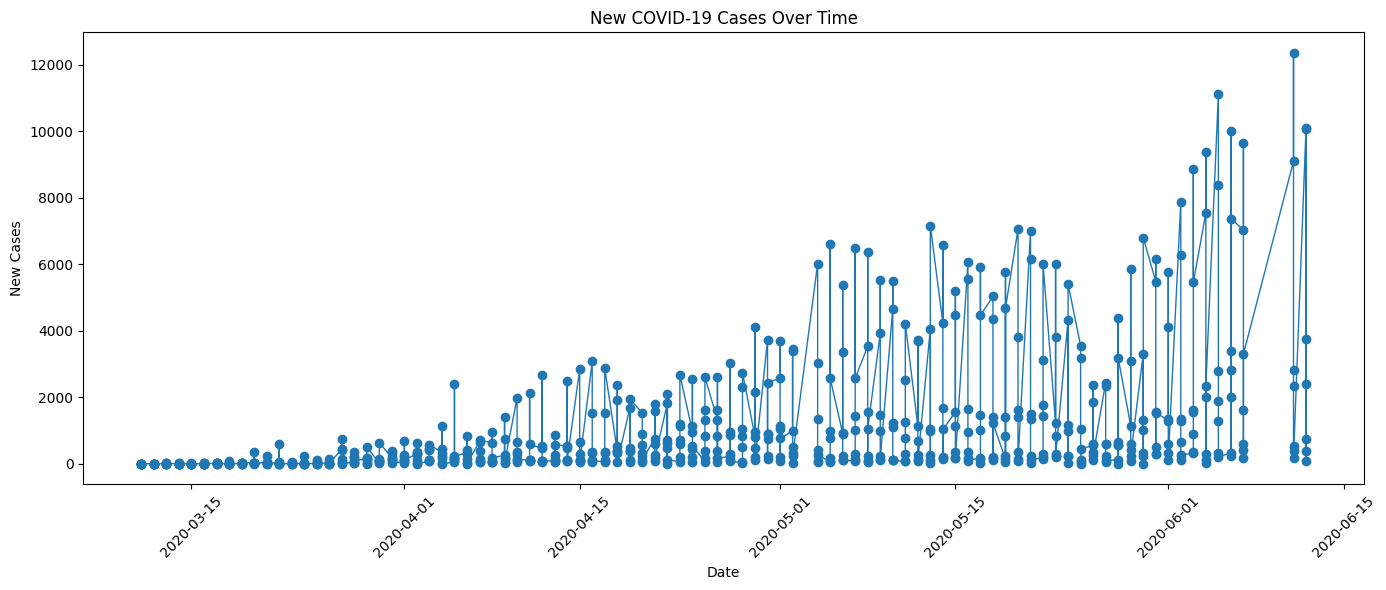

In [148]:
df = df.sort_values('Date')

plt.figure(figsize=(14, 6))

plt.plot(
    df['Date'],
    df['New (last 24 hrs)'],
    marker='o',
    linewidth=1
)

plt.title('New COVID-19 Cases Over Time')
plt.xlabel('Date')
plt.ylabel('New Cases')
plt.xticks(rotation=45)
plt.tight_layout()
plt.show()

## 13. Cumulative positive cases

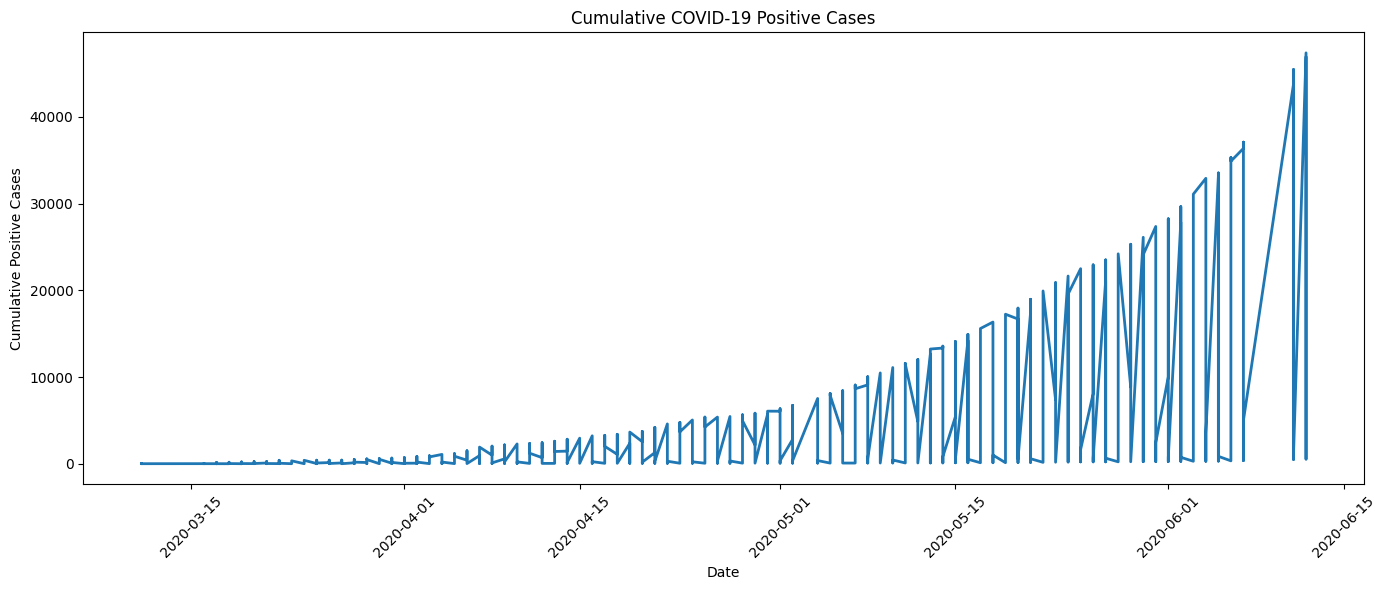

In [149]:
plt.figure(figsize=(14, 6))

plt.plot(
    df['Date'],
    df['Cumulative Test positive'],
    linewidth=2
)

plt.title('Cumulative COVID-19 Positive Cases')
plt.xlabel('Date')
plt.ylabel('Cumulative Positive Cases')
plt.xticks(rotation=45)
plt.tight_layout()
plt.show()

## 14. Tests performed over time

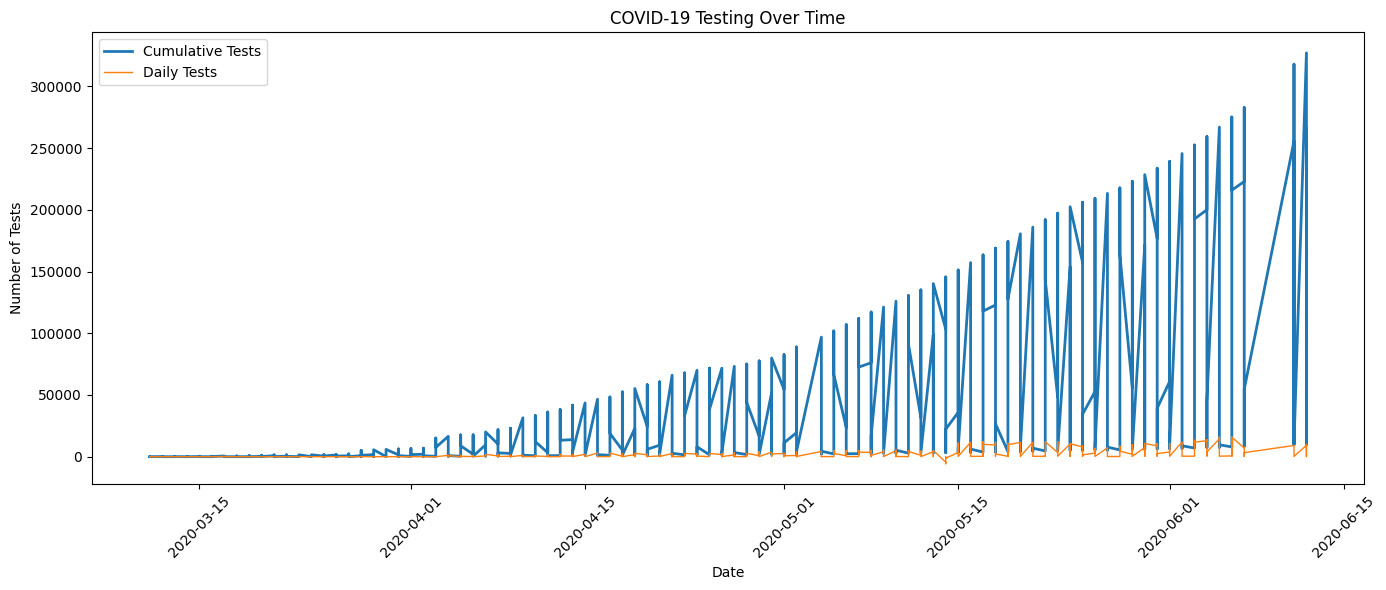

In [150]:
plt.figure(figsize=(14, 6))

plt.plot(
    df['Date'],
    df['Cumulative tests performed'],
    linewidth=2,
    label='Cumulative Tests'
)

plt.plot(
    df['Date'],
    df['Tests performed in last 24 hours'],
    linewidth=1,
    label='Daily Tests'
)

plt.title('COVID-19 Testing Over Time')
plt.xlabel('Date')
plt.ylabel('Number of Tests')
plt.legend()
plt.xticks(rotation=45)
plt.tight_layout()
plt.show()

## Active Cases Analysis
15. Current patient status

In [151]:
status_cols = [
    'Discharged',
    'Expired',
    'Home Quarantine',
    'Still admitted'
]

status_totals = df[status_cols].sum().sort_values(ascending=False)

display(status_totals)

Home Quarantine    1218397.0
Discharged          746404.0
Still admitted      304089.0
Expired              47956.0
dtype: float64

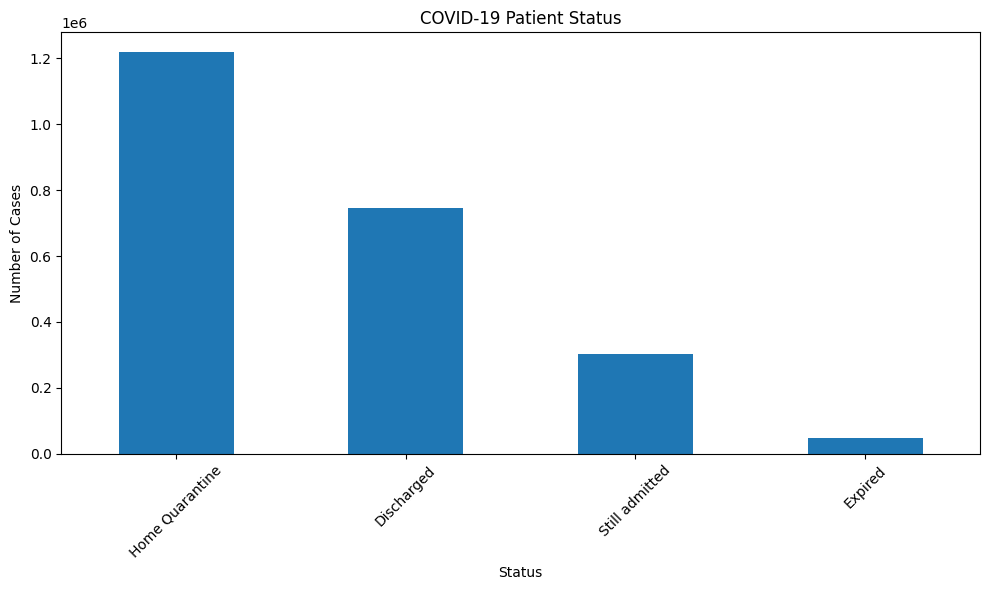

In [152]:
plt.figure(figsize=(10, 6))

status_totals.plot(kind='bar')

plt.title('COVID-19 Patient Status')
plt.xlabel('Status')
plt.ylabel('Number of Cases')
plt.xticks(rotation=45)
plt.tight_layout()
plt.show()

## Regional Visualization
16. Positive cases by region

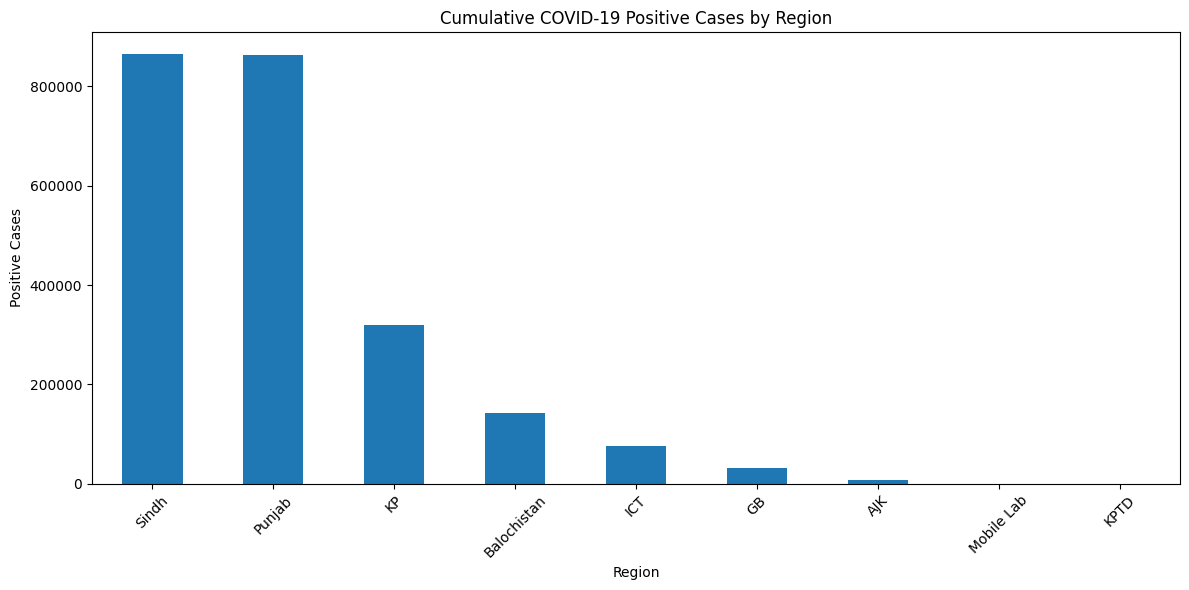

In [153]:
region_positive = (
    df.groupby('Region')['Cumulative Test positive']
    .sum()
    .sort_values(ascending=False)
)

plt.figure(figsize=(12, 6))

region_positive.plot(kind='bar')

plt.title('Cumulative COVID-19 Positive Cases by Region')
plt.xlabel('Region')
plt.ylabel('Positive Cases')
plt.xticks(rotation=45)
plt.tight_layout()
plt.show()

## 17. Discharged, expired and admitted by region

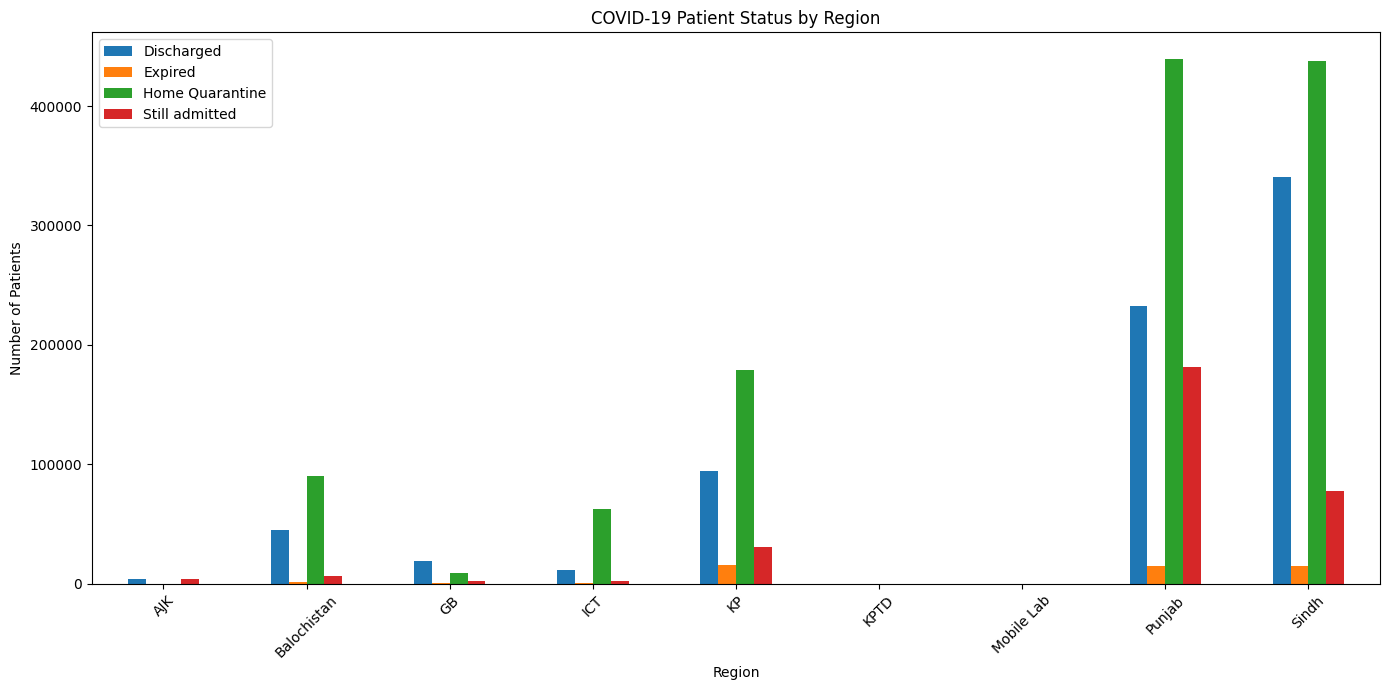

In [154]:
region_status = df.groupby('Region')[
    ['Discharged', 'Expired', 'Home Quarantine', 'Still admitted']
].sum()

region_status.plot(
    kind='bar',
    figsize=(14, 7)
)

plt.title('COVID-19 Patient Status by Region')
plt.xlabel('Region')
plt.ylabel('Number of Patients')
plt.xticks(rotation=45)
plt.tight_layout()
plt.show()

## Correlation Analysis
18. Correlation matrix

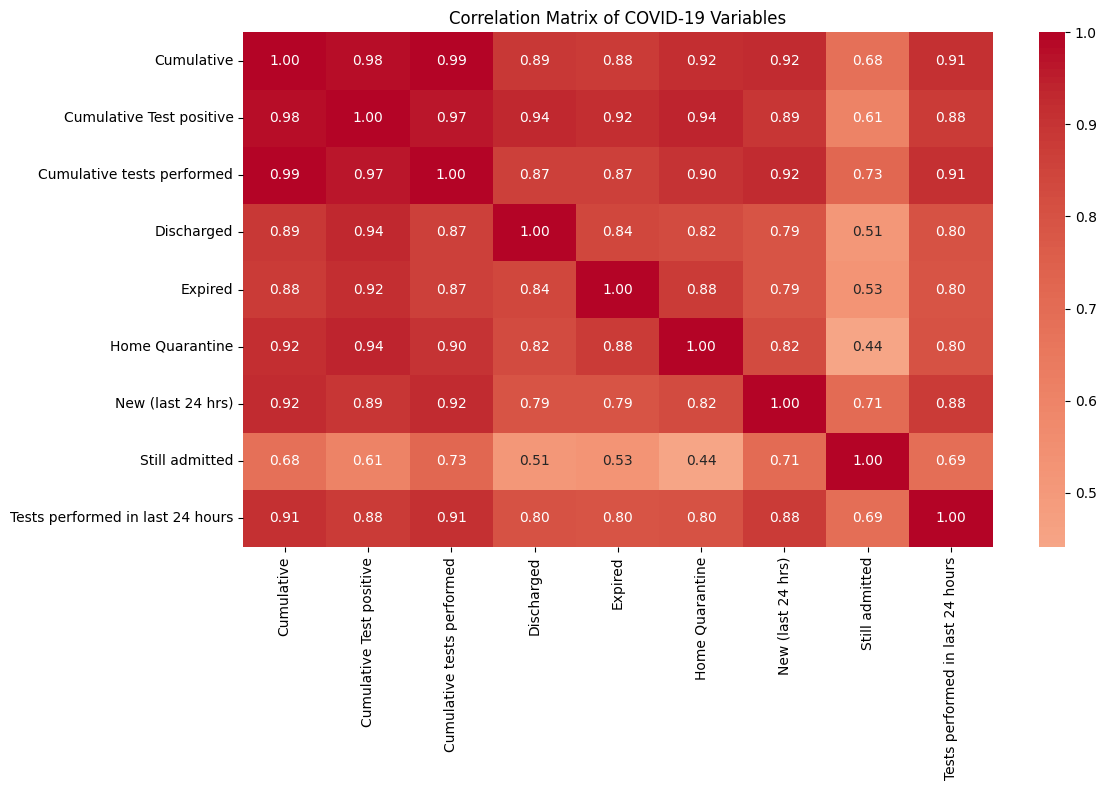

In [155]:
corr = df[numeric_cols].corr()

plt.figure(figsize=(12, 8))

sns.heatmap(
    corr,
    annot=True,
    fmt='.2f',
    cmap='coolwarm',
    center=0
)

plt.title('Correlation Matrix of COVID-19 Variables')
plt.tight_layout()
plt.show()

## Calculate COVID Indicators
19. Test positivity rate

A useful EDA variable is:

Positivity Rate = Positive Tests / Total Tests × 100

In [156]:
df['Positivity Rate (%)'] = (
    df['Cumulative Test positive'] /
    df['Cumulative tests performed'] * 100
)

df['Positivity Rate (%)'] = (
    df['Positivity Rate (%)']
    .replace([np.inf, -np.inf], np.nan)
)

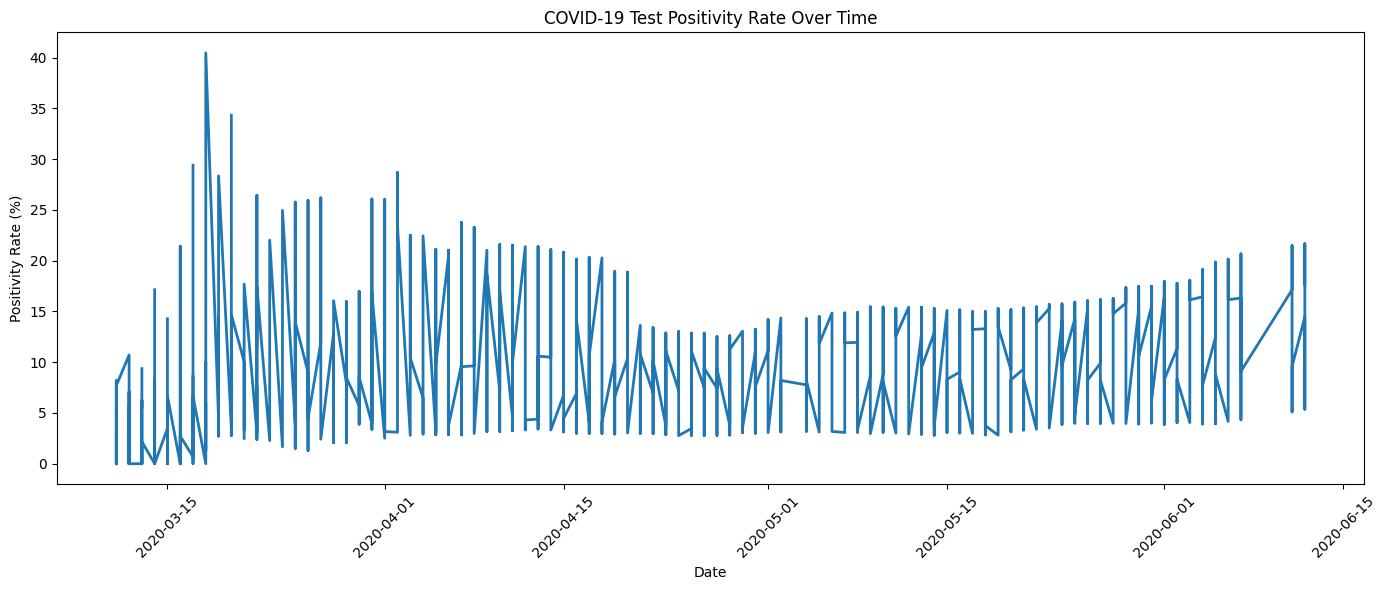

In [157]:
plt.figure(figsize=(14, 6))

plt.plot(
    df['Date'],
    df['Positivity Rate (%)'],
    linewidth=2
)

plt.title('COVID-19 Test Positivity Rate Over Time')
plt.xlabel('Date')
plt.ylabel('Positivity Rate (%)')
plt.xticks(rotation=45)
plt.tight_layout()
plt.show()

## 20. Case fatality rate

In [158]:
df['Case Fatality Rate (%)'] = (
    df['Expired'] /
    df['Cumulative Test positive'] * 100
)

df['Case Fatality Rate (%)'] = (
    df['Case Fatality Rate (%)']
    .replace([np.inf, -np.inf], np.nan)
)

## Final Clean Dataset

At the end, check everything:

In [159]:
print("Final shape:", df.shape)

print("\nMissing values:")
display(df.isna().sum())

print("\nData types:")
print(df.dtypes)

print("\nDuplicate rows:")
print(df.duplicated().sum())

print("\nFinal dataset:")
display(df.head())

Final shape: (643, 13)

Missing values:


Cumulative                           0
Cumulative Test positive             0
Cumulative tests performed           0
Date                                 0
Discharged                           0
Expired                              0
Home Quarantine                      0
New (last 24 hrs)                    0
Region                               0
Still admitted                       0
Tests performed in last 24 hours     1
Positivity Rate (%)                 12
Case Fatality Rate (%)              31
dtype: int64


Data types:
Cumulative                                   int64
Cumulative Test positive                     int64
Cumulative tests performed                   int64
Date                                datetime64[ns]
Discharged                                   int64
Expired                                      int64
Home Quarantine                            float64
New (last 24 hrs)                            int64
Region                                      object
Still admitted                               int64
Tests performed in last 24 hours           float64
Positivity Rate (%)                        float64
Case Fatality Rate (%)                     float64
dtype: object

Duplicate rows:
0

Final dataset:


,Cumulative,Cumulative Test positive,Cumulative tests performed,Date,Discharged,Expired,Home Quarantine,New (last 24 hrs),Region,Still admitted,Tests performed in last 24 hours,Positivity Rate (%),Case Fatality Rate (%)
0,48,2,80,2020-03-11,0,0,0.0,3,ICT,2,8.0,2.500000,0.0
1,61,0,95,2020-03-11,0,0,0.0,6,Punjab,0,7.0,0.000000,NaN
2,84,14,171,2020-03-11,1,0,0.0,1,Sindh,13,55.0,8.187135,0.0
3,20,0,28,2020-03-11,0,0,0.0,0,KP,0,2.0,0.000000,NaN
4,3,0,0,2020-03-11,0,0,0.0,0,KPTD,0,0.0,NaN,NaN


In [160]:
df.to_csv('COVID19_cleaned.csv', index=False)

Recommended EDA sequence

For your dataset, I would follow this order:

Data loading → Column cleaning → Missing values → Duplicate check → Date conversion → Numeric conversion → Descriptive statistics → Region analysis → Time-series analysis → Patient-status analysis → Testing analysis → Positivity rate → Fatality rate → Correlation analysis.